In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Loading the dataset
df = pd.read_csv('Fraud_Detection_Data.csv')

# 1. Please load the transactional CSV dataset, Fraud_Detection_Data Download Fraud_Detection_Data, which was originally captured to aid in detecting potential fraud in business transactions in a US based company. Display the default head and tail of the dataset and provide 2 screenshots of your results.

In [3]:
# Displaying first 5 rows
df.head()

,CCARD_NUM,TRANSACT_DATE,VENDOR_NUM,VENDOR_DESCRIPTION,VENDOR_STATE,VENDOR_ZIP,TRANSACT_TYPE,TRANSACT_AMOUNT
0,5142283016,17-7-2010,930090121224,FEDEX SHP 07/12/10 AB#,TN,38118.0,P,"$15,13"
1,5142302629,1-9-2010,602608969284,FISHER SCI HUS,TX,77251.0,P,"$57,21"
2,5142152067,22-8-2010,930090121224,FEDEX SHP 08/17/10 AB#,TN,38118.0,P,"$16,18"
3,5142190387,30-5-2010,298960098335,LUDLUM MEASUREMENTS,TX,79556.0,P,"$43,50"
4,5142265645,12-10-2010,456610646335,AMERICAN INST OF PHYSICS,NY,11753.0,P,"$105,00"


In [4]:
# Displaying last 5 rows
df.tail()

,CCARD_NUM,TRANSACT_DATE,VENDOR_NUM,VENDOR_DESCRIPTION,VENDOR_STATE,VENDOR_ZIP,TRANSACT_TYPE,TRANSACT_AMOUNT
95071,5142200915,28-1-2010,688600712,HANS RUDOLPH INC,MO,64114.0,P,"$1.606,40"
95072,5142149874,22-7-2010,930090121224,FEDEX SHP 07/18/10 AB#,TN,38118.0,P,"$3,62"
95073,5142139554,28-9-2010,930090121224,FEDEX SHP 09/20/10 AB#,TN,38118.0,P,"$3,62"
95074,5142151400,6-1-2010,5206100988784,FRAME OF MINE,DC,20003.0,P,"$41,00"
95075,5142149253,6-3-2010,951053079229,COMPASS,MA,1702.0,P,"$595,00"


In [5]:
df.dtypes

CCARD_NUM               int64
TRANSACT_DATE          object
VENDOR_NUM             object
VENDOR_DESCRIPTION     object
VENDOR_STATE           object
VENDOR_ZIP            float64
TRANSACT_TYPE          object
TRANSACT_AMOUNT        object
dtype: object

# 2. Split the column TRANSACT_DATE into three differnt columns to indicate the Transaction_Day, Transaction_Month and Transaction_Year, all in numeric formats.

In [6]:
# Converting TRANSACT_DATE to datetime object for reading the values in that format.
df['TRANSACT_DATE'] = pd.to_datetime(df['TRANSACT_DATE'], errors='coerce')

# Extracting day, month, year from Transact date column by reading datetime values.
df['Transaction_Day'] = df['TRANSACT_DATE'].dt.day
df['Transaction_Month'] = df['TRANSACT_DATE'].dt.month
df['Transaction_Year'] = df['TRANSACT_DATE'].dt.year

# Displaying first five rows
df[['TRANSACT_DATE', 'Transaction_Day', 'Transaction_Month', 'Transaction_Year']].head()


/var/folders/2h/d72vcx3n45q8sr7vv6zmq2q40000gp/T/ipykernel_93674/2698570004.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['TRANSACT_DATE'] = pd.to_datetime(df['TRANSACT_DATE'], errors='coerce')


,TRANSACT_DATE,Transaction_Day,Transaction_Month,Transaction_Year
0,2010-07-17,17,7,2010
1,2010-09-01,1,9,2010
2,2010-08-22,22,8,2010
3,2010-05-30,30,5,2010
4,2010-10-12,12,10,2010


# 3. Clean up the VENDOR_ZIP column to show valid US ZIP codes.

In [7]:
# Keep only numeric values by excluding NaN
df['VENDOR_ZIP'] = df['VENDOR_ZIP'].astype(str).str.extract('(\d{5})')[0]

# Converting to numeric format
df['VENDOR_ZIP'] = pd.to_numeric(df['VENDOR_ZIP'], errors='coerce')

df['VENDOR_ZIP']


0        38118.0
1        77251.0
2        38118.0
3        79556.0
4        11753.0
          ...   
95071    64114.0
95072    38118.0
95073    38118.0
95074    20003.0
95075        NaN
Name: VENDOR_ZIP, Length: 95076, dtype: float64

In [8]:
# checking for NaN's
nan_counts = df['VENDOR_STATE'].isna().sum()
print(nan_counts)

1192


# 4.Clean up and reformat the TRANSACT_AMOUNT column to all numerice amounts so that mathematical computations can be performed on them.

In [9]:
# Removing currency symbols and commas from transaction amount column
df['TRANSACT_AMOUNT'] = df['TRANSACT_AMOUNT'].replace('[\$,]', '', regex=True)

# Converting to float
df['TRANSACT_AMOUNT'] = pd.to_numeric(df['TRANSACT_AMOUNT'], errors='coerce')

# Checking result
df['TRANSACT_AMOUNT']


0         1513.0000
1         5721.0000
2         1618.0000
3         4350.0000
4        10500.0000
            ...    
95071        1.6064
95072      362.0000
95073      362.0000
95074     4100.0000
95075    59500.0000
Name: TRANSACT_AMOUNT, Length: 95076, dtype: float64

# 5. Visualize the total transactional amounts by state and indicate the states with the Least and the Most total transactional amounts.

In [10]:
# Ensuring the column exists and has no missing values
df['VENDOR_STATE'] = df['VENDOR_STATE'].str.upper()  # standardize state names
state_totals = df.groupby('VENDOR_STATE')['TRANSACT_AMOUNT'].sum()


In [11]:
# Converting every state to string
df['VENDOR_STATE'] = df['VENDOR_STATE'].astype(str)

# Cleaning - keeping only alphabetic entries, converting others to NaN
df['VENDOR_STATE'] = df['VENDOR_STATE'].apply(lambda x: x.strip().upper() if x.isalpha() else np.nan)

# displaying the first 10 rows
df['VENDOR_STATE'].head(10)


0    TN
1    TX
2    TN
3    TX
4    NY
5    OR
6    UT
7    IL
8    WA
9    VA
Name: VENDOR_STATE, dtype: object

State with least total amount: MB -> 10874.0
State with most total amount: CA -> 148544280.93398


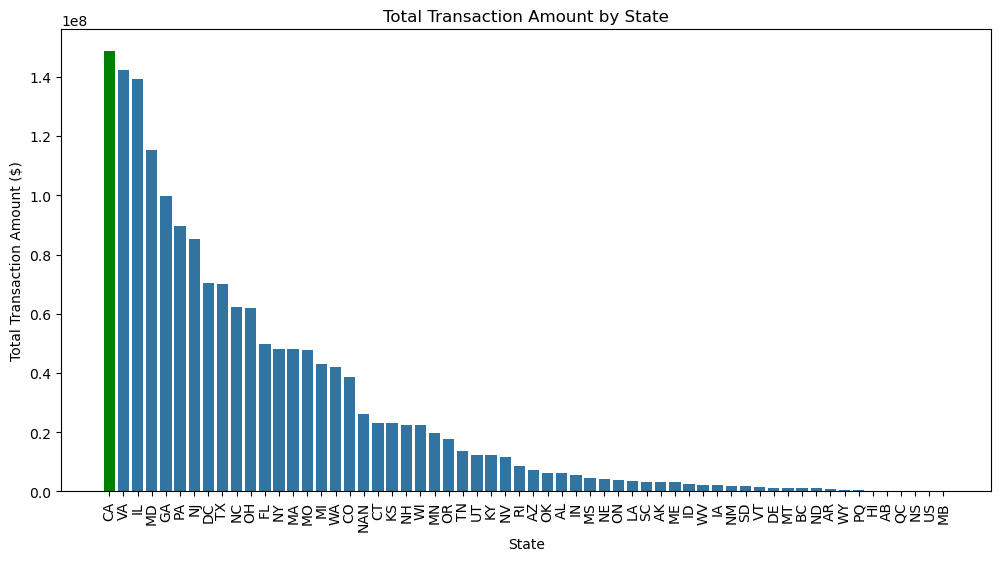

In [12]:
# Cleaning VENDOR_STATE column 
df['VENDOR_STATE'] = df['VENDOR_STATE'].str.upper().str.strip()

# Aggregating the total transaction amounts by state
state_totals = df.groupby('VENDOR_STATE')['TRANSACT_AMOUNT'].sum()

# Identifying least and most transactional amounts
least_state = state_totals.idxmin()
most_state = state_totals.idxmax()

print(f"State with least total amount: {least_state} -> {state_totals.min()}")
print(f"State with most total amount: {most_state} -> {state_totals.max()}")

# Sorting the values for plotting
state_totals_sorted = state_totals.sort_values(ascending=False)

# Plotting bar chart
plt.figure(figsize=(12,6))
sns.barplot(x=state_totals_sorted.index, y=state_totals_sorted.values)
plt.xticks(rotation=90)
plt.title("Total Transaction Amount by State")
plt.ylabel("Total Transaction Amount ($)")
plt.xlabel("State")

# Highlighting least (red) and most (green)
plt.bar(state_totals_sorted.index.get_loc(least_state), 
        state_totals_sorted[least_state], color='red')
plt.bar(state_totals_sorted.index.get_loc(most_state), 
        state_totals_sorted[most_state], color='green')

plt.show()
